# **Recommender Systems**
A recommender system suggests items a user is likely to find useful, relevant, or enjoyable. The same core idea appears across modern platforms: Netflix recommends movies, Amazon recommends products, YouTube recommends videos, Spotify recommends music, and Coursera recommends courses. The main challenge is to rank possible items so the most useful ones appear first.


## **Main Types**
Recommender systems can be organized into three main families: popularity-based methods, content-based methods, and collaborative filtering. Popularity-based systems use aggregate behavior, content-based systems use item and user features, and collaborative filtering learns from patterns in user-item interactions.

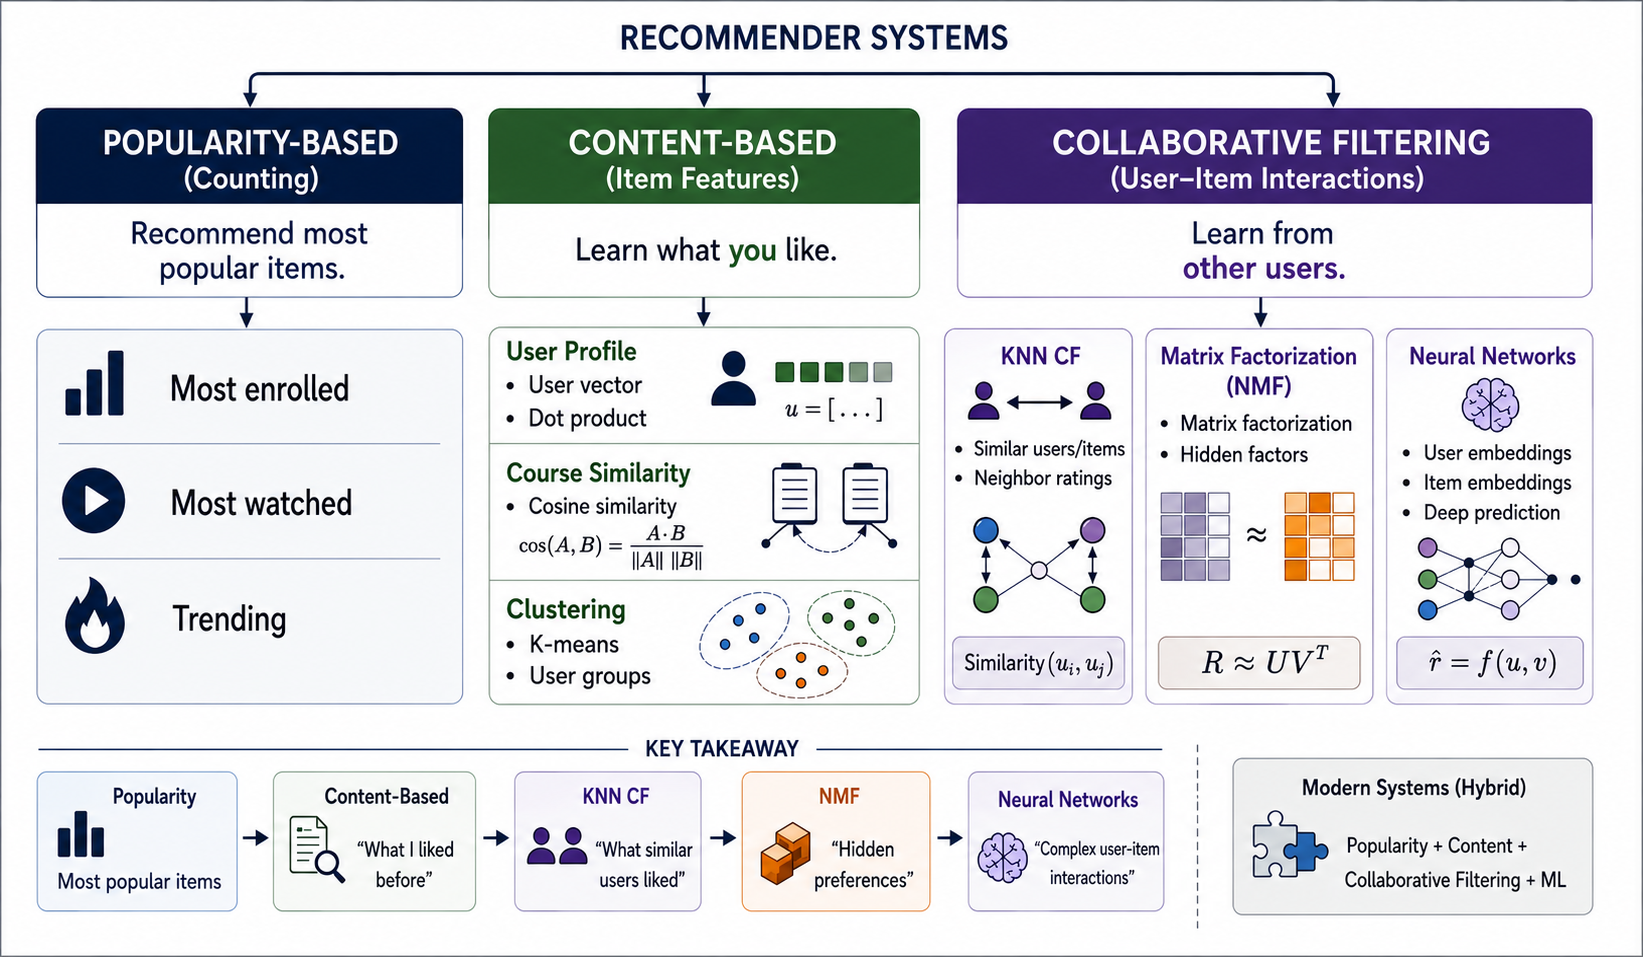


### **1. Counting / Popularity-Based Recommender**
A popularity-based recommender is the simplest baseline. It recommends the most frequent, most watched, most purchased, most enrolled, or currently trending items. This works well when no user-specific information is available, but every user receives essentially the same recommendations, so personalization is limited.


### **2. Content-Based Recommender**
A content-based recommender suggests items similar to items the user liked before. It depends on item features such as genres, keywords, tags, or bag-of-words vectors, then uses the user's own history to build personalized recommendations. In this capstone setting, course features such as genres or BoW vectors can be matched against a user's previous enrollments.


#### **2.1. Content-Based User Profile**
The user-profile approach represents each user as a preference vector built from enrolled courses and their feature vectors. New courses are ranked by how strongly their features align with that user profile.

User profile:
$$
\text{User Profile} = \sum (\text{enrolled courses} \times \text{genre vector})
$$

Score:
$$
\text{Score} = \text{User Profile} \cdot \text{Course Feature Vector}
$$

For example, BoW or genre vectors describe each course, the user profile becomes a weighted sum of those course vectors, and the highest-scoring unseen courses are recommended. This method is interpretable and does not need data from other users. It can also help with new items if their features are known. Its main limitation is overspecialization: it tends to recommend items very similar to what the user already consumed, and its quality depends heavily on feature engineering.


#### **2.2. Content-Based Course Similarity**
Course-similarity recommenders compare course feature vectors directly and recommend courses similar to those already enrolled by the user. A common similarity measure is cosine similarity:

$$
\text{sim}(A, B) = \frac{A \cdot B}{\|A\| \|B\|}
$$

The workflow is straightforward: compute similarities between course vectors, rank candidate courses, and recommend the top-N unseen courses. This method is simple, fast, and easy to explain, but it mainly finds close substitutes and is weak at discovering new user interests.


#### **2.3. Clustering-Based Recommender with K-Means**
A clustering-based recommender groups users with similar profiles, then recommends popular courses within the same cluster. PCA may be used first to reduce dimensionality, and K-means then assigns users to groups by minimizing within-cluster variance:

$$
\sum ||x_i - \mu_k||^2
$$

After clustering, recommendations can be drawn from courses that are common among similar users in the same group. This approach scales well and captures broad group-level patterns, but it is less personalized than direct user-level ranking and depends on the quality of the learned clusters.


### **3. Collaborative Filtering-Based Recommender**
Collaborative filtering uses the user-item interaction matrix and learns from the behavior of other users. Instead of relying on course features, it identifies patterns such as users with similar enrollments or items that tend to be consumed together.

#### **3.1. Collaborative Filtering with KNN**
KNN collaborative filtering predicts a user's interest from nearby users or nearby items. In user-based CF, the system finds users similar to the current user; if User A likes courses A and B, while User B likes A, B, and C, then C becomes a candidate recommendation for User A. In item-based CF, the system finds items similar to what the user liked; if many users who liked movie A also liked movie B, then B is recommended to users who liked A.

The predicted rating can be computed as a similarity-weighted average from neighbors:

$$
\hat{r}_{ui} = \frac{\sum_{v} \text{sim}(u,v) \cdot r_{vi}}{\sum_{v} |\text{sim}(u,v)|}
$$

In practice, a library such as Surprise can implement KNN with cosine similarity and predict missing ratings. KNN can discover interests not captured by explicit features and requires little feature engineering, but it struggles with sparse interaction data, cold-start users or items, and high computational cost at scale.


#### **3.2. Collaborative Filtering with NMF**
Non-negative matrix factorization decomposes the user-item matrix into lower-dimensional latent factors. These hidden factors summarize user preferences and item characteristics, then reconstruct missing ratings through matrix multiplication:

$$
R \approx U \cdot V^T
$$

NMF usually handles sparsity better than neighbor-based KNN and can capture meaningful latent patterns. The tradeoff is interpretability: the learned factors may be useful for prediction but harder to explain directly. Like other collaborative filtering methods, NMF also has a cold-start problem when there is no interaction history.


#### **3.3. Neural Network-Based Recommender**
Neural recommenders learn user and item embeddings, then pass those representations through a model to predict ratings, clicks, enrollments, or other interactions.

Embedding:
$$
u = E_{\text{user}}(ID), \quad v = E_{\text{item}}(ID)
$$

Prediction:
$$
\hat{r} = f(u, v)
$$

A typical model maps each user ID and item ID to embedding vectors, combines them, and predicts the expected interaction. Neural models can capture nonlinear relationships and can be extended into hybrid systems that include metadata, text, or context. Their disadvantages are higher data requirements, higher computational cost, and lower interpretability.


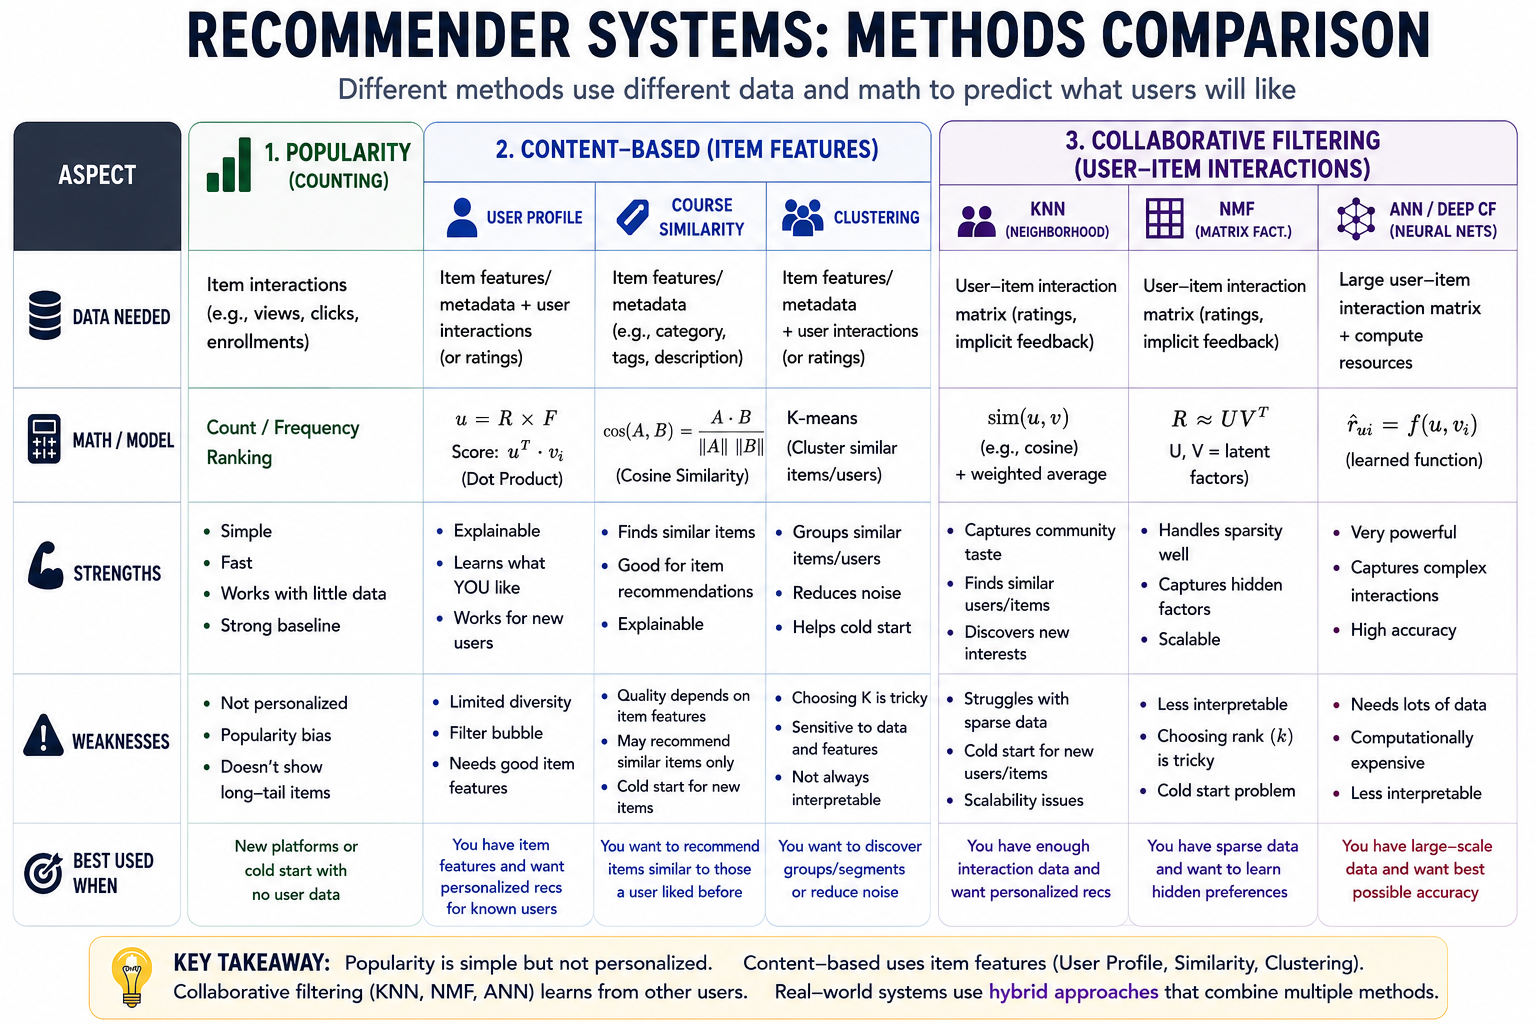

## **Example in Capstone Project**

| Lab             | Type         |
| --------------- | ------------ |
| popularity      | counting     |
| BoW similarity  | content      |
| user similarity | user-CF      |
| item similarity | item-CF      |
| clustering      | ML helper    |
| embeddings      | content / CF |

The capstone touches the major recommendation families: popularity methods provide a baseline, BoW similarity supports content-based ranking, user and item similarity implement collaborative filtering, clustering adds an ML grouping strategy, and embeddings provide dense representations for either content-based or collaborative models.
